# Exercise 3: Neural networks in PyTorch

In this exercise you’ll implement small neural-network building blocks from scratch and use them to train a simple classifier.

You’ll cover:
- **Basic layers**: Linear, Embedding, Dropout
- **Normalization**: LayerNorm and RMSNorm
- **MLPs + residual**: composing layers into deeper networks
- **Classification**: generating a learnable dataset, implementing cross-entropy from logits, and writing a minimal training loop

As before: fill in all `TODO`s without changing function names or signatures.
Use small sanity checks and compare to PyTorch reference implementations when useful.

In [5]:
from __future__ import annotations

import torch
from torch import nn

`## Basic layers

In this section you’ll implement a few core layers that appear everywhere:

### `Linear`
A fully-connected layer that follows nn.Linear conventions:  
`y = x @ Wᵀ + b`

Important details:
- Parameters should be registered as `nn.Parameter`
- Store weight as (out_features, in_features) like nn.Linear.
- The forward pass should support leading batch dimensions: `x` can be shape `(..., in_features)`

### `Embedding`
An embedding table maps integer ids to vectors:
- input: token ids `idx` of shape `(...,)`
- output: vectors of shape `(..., embedding_dim)`

This is essentially a learnable lookup table.

### `Dropout`
Dropout randomly zeroes activations during training to reduce overfitting.
Implementation details:
- Only active in `model.train()` mode
- In training: drop with probability `p` and scale the kept values by `1/(1-p)` so the expected value stays the same
- In eval: return the input unchanged

## Instructions
- Do not use PyTorch reference modules for the parts you implement (e.g. don’t call nn.Linear inside your Linear).
- You may use standard tensor ops that you learned before (matmul, sum, mean, rsqrt, indexing, etc.).
- Use a parameter initialization method of your choice. We recommend something like Xavier-uniform.
`

In [6]:
class Linear(nn.Module):
    def __init__(self, in_features: int, out_features: int, bias: bool = True):
        super().__init__()
        
        self.in_features = in_features
        self.out_features = out_features
        self.weight = nn.Parameter(torch.zeros(out_features, in_features))
        self.bias = nn.Parameter(torch.zeros(out_features)) if bias else None

        nn.init.xavier_uniform_(self.weight)
        if self.bias is not None:
            nn.init.zeros_(self.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (..., in_features)
        return: (..., out_features)
        """
        out = x @ self.weight.T
        if self.bias is not None:
            out = out + self.bias

        return out

In [7]:
class Embedding(nn.Module):
    def __init__(self, num_embeddings: int, embedding_dim: int):
        super().__init__()
        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim
        self.weight = nn.Parameter(torch.zeros(num_embeddings, embedding_dim))

    def forward(self, idx: torch.Tensor) -> torch.Tensor:
        """
        idx: (...,) int64
        return: (..., embedding_dim)
        """
        return self.weight[idx]
        

In [8]:
class Dropout(nn.Module):
    def __init__(self, p: float):
        super().__init__()
        self.p = p

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        In train mode: drop with prob p and scale by 1/(1-p).
        In eval mode: return x unchanged.
        """
        if self.training:
            scale = 1 / (1-self.p)
            x = x * torch.bernoulli(torch.full_like(x,1-self.p)) * scale

        return x

## Normalization

Normalization layers help stabilize training by controlling activation statistics.

### LayerNorm
LayerNorm normalizes each example across its **feature dimension** (the last dimension):

- compute mean and variance over the last dimension
- normalize: `(x - mean) / sqrt(var + eps)`
- apply learnable per-feature scale and shift (`weight`, `bias`)

**In this exercise, assume `elementwise_affine=True` (always include `weight` and `bias`).**  
`weight` and `bias` each have shape `(D,)`.

LayerNorm is widely used in transformers because it does not depend on batch statistics.

### RMSNorm
RMSNorm is similar to LayerNorm but normalizes using only the root-mean-square:
- `x / sqrt(mean(x^2) + eps)` over the last dimension
- usually includes a learnable scale (`weight`)
- no mean subtraction

RMSNorm is popular in modern LLMs because it's faster.


In [9]:
class LayerNorm(nn.Module):
    def __init__(
        self, normalized_shape: int, eps: float = 1e-5, elementwise_affine: bool = True
    ):
        super().__init__()
        self.normalized_shape = normalized_shape
        self.eps = eps
        self.elementwise_affine = elementwise_affine
        if self.elementwise_affine:
            self.weight = nn.Parameter(torch.ones(normalized_shape))
            self.bias = nn.Parameter(torch.zeros(normalized_shape))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Normalize over the last dimension.
        x: (..., D)
        """
        mean = x.mean(dim=-1, keepdim=True)
        variance = x.var(dim=-1, keepdim=True, unbiased=False)
        normalized = (x-mean) / torch.sqrt(variance + self.eps)

        if self.elementwise_affine:
            normalized = self.weight * normalized + self.bias

        return normalized

In [10]:
class RMSNorm(nn.Module):
    def __init__(self, normalized_shape: int, eps: float = 1e-8):
        super().__init__()
        self.normalized_shape = normalized_shape
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(normalized_shape))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        RMSNorm: x / sqrt(mean(x^2) + eps) * weight
        over the last dimension.
        """
        
        variance = x.pow(2).mean(dim=-1, keepdim=True)
        normalized = x / torch.sqrt(variance + self.eps)
        
        return normalized * self.weight

## MLPs and residual networks

Now you’ll build larger networks by composing layers.

### MLP
An MLP is a stack of `depth` Linear layers with non-linear activations (use GELU) in between.
In this exercise you’ll support:
- configurable depth
- a hidden dimension
- optional LayerNorm between layers (a common stabilization trick)

A key skill is building networks using `nn.ModuleList` / `nn.Sequential` while keeping shapes consistent.

### Transformer-style FeedForward (FFN)
A transformer block contains a position-wise feedforward network:
- `D -> 4D -> D` (by default)
- activation is typically **GELU**

This is essentially an MLP applied independently at each token position.

### Residual wrapper
Residual connections are the simplest form of “skip connection”:
- output is `x + fn(x)`

They improve gradient flow and allow training deeper networks more reliably.

In [11]:
class MLP(nn.Module):
    def __init__(
        self,
        in_dim: int,
        hidden_dim: int,
        out_dim: int,
        depth: int,
        use_layernorm: bool = False,
    ):
        super().__init__()
        self.use_layernorm = use_layernorm

        if self.use_layernorm:
            layers = [Linear(in_dim,hidden_dim), LayerNorm(hidden_dim), nn.GELU()]
        else:
            layers = [Linear(in_dim,hidden_dim), nn.GELU()]

        for _ in range(depth-2):
            layers.append(Linear(hidden_dim,hidden_dim), )
            if self.use_layernorm:
                layers.append(LayerNorm(hidden_dim))
            layers.append(nn.GELU())
        
        layers.append(Linear(hidden_dim,out_dim))

        self.model = nn.Sequential(*layers)                

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)

In [12]:
class FeedForward(nn.Module):
    """
    Transformer-style FFN: D -> 4D -> D (default)
    """

    def __init__(self, d_model: int, d_ff: int | None = None):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        self.model = nn.Sequential(
            Linear(d_model,d_ff),
            nn.GELU(),
            Linear(d_ff,d_model)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)

In [13]:
class Residual(nn.Module):
    def __init__(self, fn: nn.Module):
        super().__init__()
        self.fn = fn

    def forward(self, x: torch.Tensor, *args, **kwargs) -> torch.Tensor:
        return self.fn(x) + x

## Classification problem

In this section you’ll put everything together in a minimal MNIST classification experiment.

You will:
1) download and load the MNIST dataset
2) implement cross-entropy from logits (stable, using log-softmax)
3) build a simple MLP-based classifier (flatten MNIST images first)
4) write a minimal training loop
5) report train loss curve and final accuracy

The goal here is not to reach state-of-the-art accuracy, but to understand the full pipeline:
data → model → logits → loss → gradients → parameter update.

### Model notes
- We want you to combine the MLP we implemented above with the classification head we define below into one model 

### MNIST notes
- MNIST images are `28×28` grayscale.
- After `ToTensor()`, each image has shape `(1, 28, 28)` and values in `[0, 1]`.
- For an MLP classifier, we flatten to a vector of length `784`.

## Deliverables
- Include a plot of your train loss curve in the video submission as well as a final accuracy. 
- **NOTE** Here we don't grade on model performance but we expect you to achieve at least 70% accuracy to confirm a correct model implementation.

In [14]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [15]:
transform = transforms.ToTensor()  # -> float32 in [0,1], shape (1, 28, 28)

train_ds = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

In [16]:
def cross_entropy_from_logits(
    logits: torch.Tensor,
    targets: torch.Tensor,
) -> torch.Tensor:
    """
    Compute mean cross-entropy loss from logits.

    logits: (B, C)
    targets: (B,) int64

    Requirements:
    - Use log-softmax for stability (do not use torch.nn.CrossEntropyLoss, we check this in the autograder).
    """

    log_probs = torch.nn.functional.log_softmax(logits, dim=-1)
    element_loss = -log_probs[torch.arange(log_probs.shape[0]), targets]
    return element_loss.mean()

In [17]:
class ClassificationHead(nn.Module):
    def __init__(self, d_in: int, num_classes: int):
        super().__init__()
        self.model = Linear(d_in, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (..., d_in)
        return: (..., num_classes) logits
        """
        return self.model(x)

In [18]:
def accuracy(model, loader):
    with torch.no_grad():
        num_correct = 0
        num_total = 0
        for batch in loader:
            images, labels = batch
            images = images.flatten(start_dim=1)
            predictions = model(images).argmax(dim=-1)
            num_correct = num_correct + (labels == predictions).sum()
            num_total = num_total + labels.shape[0]

        return num_correct / num_total        

In [ ]:
def train_classifier(
    model: nn.Module,
    train_data_loader: DataLoader,
    test_data_loader: DataLoader,
    lr: float,
    epochs: int,
    seed: int = 0,
) -> list[float]:
    """
    Minimal training loop for MNIST classification.

    Steps:
    - define optimizer
    - for each epoch:
        - sample minibatches
        - forward -> cross-entropy -> backward -> optimizer step
      - compute test accuracy at the end of each epoch
    - return list of training losses (one per update step)

    Requirements:
    - call model.train() during training and model.eval() during evaluation
    - do not use torch.nn.CrossEntropyLoss (use your cross_entropy_from_logits)
    """

    train_losses = []
    test_accuracy_per_epoch = []
    optimizer = torch.optim.AdamW(params = model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        epoch_losses = []
        for batch in train_data_loader:
            images, targets = batch
            images = images.flatten(start_dim=1)
            predictions = model(images)
            loss = cross_entropy_from_logits(predictions,targets)
            train_losses.append(loss.item())
            epoch_losses.append(loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        model.eval()
        acc = accuracy(model, test_data_loader)
        test_accuracy_per_epoch.append(acc.item())
        print(f"Epoch {epoch+1}/{epochs}, Test Accuracy: {acc:.4f}")
        print(f"Epoch {epoch+1}/{epochs}, Epoch Train Loss Average: {torch.tensor(epoch_losses).mean():.4f}")

    return train_losses


In [24]:
mlp = MLP(784, 256, 128, 4)
head = ClassificationHead(128, 10)
model = nn.Sequential(mlp,head)
train_losses = train_classifier(model, train_loader, test_loader, lr=1e-3, epochs=5)

Epoch 1/5, Test Accuracy: 0.9616
Epoch 1/5, Running Train Loss Average: 0.2147
Epoch 2/5, Test Accuracy: 0.9711
Epoch 2/5, Running Train Loss Average: 0.1516
Epoch 3/5, Test Accuracy: 0.9714
Epoch 3/5, Running Train Loss Average: 0.1211
Epoch 4/5, Test Accuracy: 0.9788
Epoch 4/5, Running Train Loss Average: 0.1021
Epoch 5/5, Test Accuracy: 0.9746
Epoch 5/5, Running Train Loss Average: 0.0889


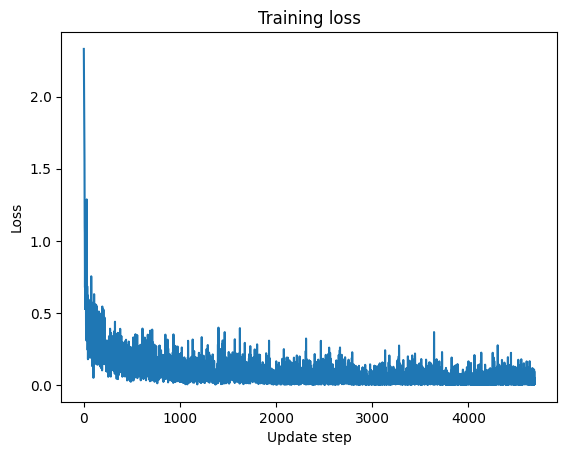

In [ ]:
#import matplotlib.pyplot as plt

plt.plot(train_losses)
plt.xlabel("Update step")
plt.ylabel("Loss")
plt.title("Training loss")
plt.savefig("train_loss.png")
plt.show()